# Check inelastic

In [22]:
# imports
from importlib import reload
import os
import numpy as np

from matplotlib import pyplot as plt

import xarray
import pandas
from scipy.interpolate import interp1d

from ocpy.pace import io as pace_io
from ocpy.utils import plotting
from ocpy.hydrolight import loisel23
from ocpy.utils import coords as ocpy_coords
from ocpy.water import scattering

from bing.parameters import standard
from bing.models import utils as model_utils
from bing.priors import priors as bing_priors
from bing.fitting import inference as bing_inf
from bing import evaluate
from bing.fitting import chisq_fit
from bing import plotting as bing_plotting

# Locals
from grab_pace_granules import load_from_json
import fitting as m_fitting
import grab_pace_granules

# Load up L23

In [7]:
l23_10 = loisel23.load_ds(1,0)
l23_20 = loisel23.load_ds(2,0)
l23_40 = loisel23.load_ds(4,0)
#
wave = l23_10.Lambda

In [8]:
def grab_data(idx):
    return l23_10.Rrs[idx], l23_20.Rrs[idx], l23_40.Rrs[idx]

# Plot an example

In [9]:
idx = 170
Rrs_10, Rrs_20, Rrs_40 = grab_data(idx)

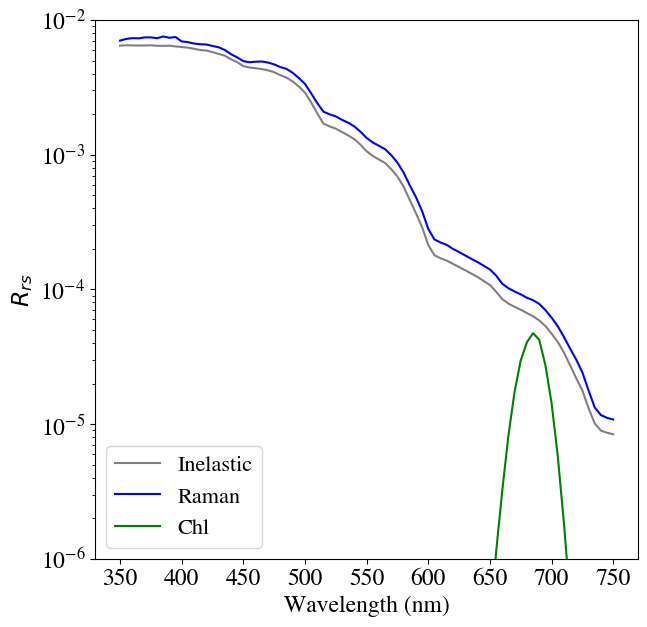

In [15]:
fig = plt.figure(figsize=(7,7))
ax = plt.gca()
#
ax.plot(wave, Rrs_10, label='Inelastic', color='gray')
ax.plot(wave, Rrs_20, label='Raman', color='blue')
ax.plot(wave, Rrs_40-Rrs_20, label='Chl', color='green')
#
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel(r'$R_{rs}$')
ax.set_yscale('log')
ax.set_ylim(1e-6, 1e-2)
plotting.set_fontsize(ax, 17.)
ax.legend(loc='lower left', fontsize=16.)
plt.show()

## Relative

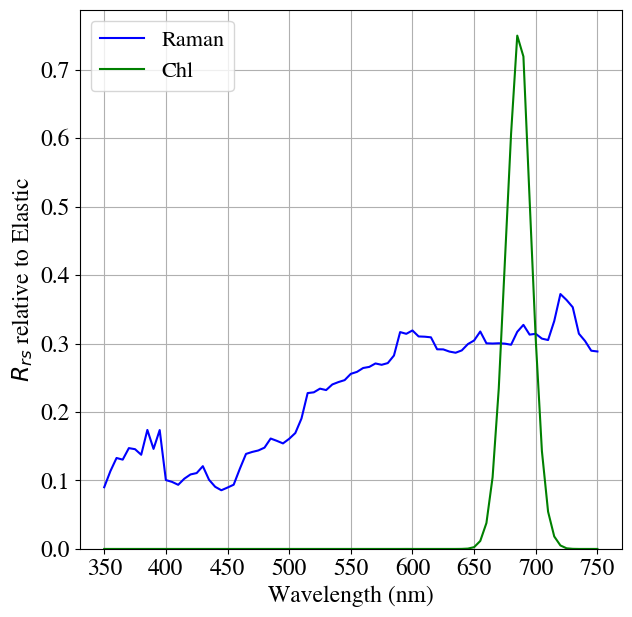

In [40]:
fig = plt.figure(figsize=(7,7))
ax = plt.gca()
#
ax.plot(wave, (Rrs_20-Rrs_10)/Rrs_10, label='Raman', color='blue')
ax.plot(wave, (Rrs_40-Rrs_20)/Rrs_10, label='Chl', color='green')
#
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel(r'$R_{rs}$ relative to Elastic')
#ax.set_yscale('log')
ax.grid()
ax.set_ylim(0., None)
plotting.set_fontsize(ax, 17.)
ax.legend(loc='upper left', fontsize=16.)
plt.show()

# Gordon 1999 writes that "two-flow models of radiative transfer show that the ratio of the Raman to the elastic contributions to $E_u$ should be roughly proportional to:

# $\frac{a(\lambda)}{a(\lambda) + a(\lambda_e)}$

## where $\lambda_e$ is the wavelength of light that would excite Raman emission at wavelength $\lambda$

In [28]:
def calc_Raman_to_Elastic(wv, a, awave):
    # Generate interpolator
    f_a = interp1d(awave, a)
    #
    wv_e = calc_le(wv)
    a_i = f_a(wv)
    a_e = f_a(wv_e)
    # Finish
    return a_i / (a_i + a_e)

## Furthermore, Mobley reports that:

# $\lambda = \frac{10^7}{\frac{10^7}{\lambda_e} - 3400}$

## with $\lambda$ in nm

# Inverting the last equation

# $\lambda_e = \frac{10^7}{\frac{10^7}{\lambda} + 3400}$

In [18]:
def calc_le(l):
    return 1e7 / (1e7/l + 3400)

In [19]:
calc_le(583.)

486.55505666739

In [21]:
calc_le(400.)

352.11267605633805

# Let's approximate

In [25]:
a = l23_10.a[idx]

In [29]:
wv = np.linspace(400, 600, 200)
R_E = calc_Raman_to_Elastic(wv, a, wave)

## Plot

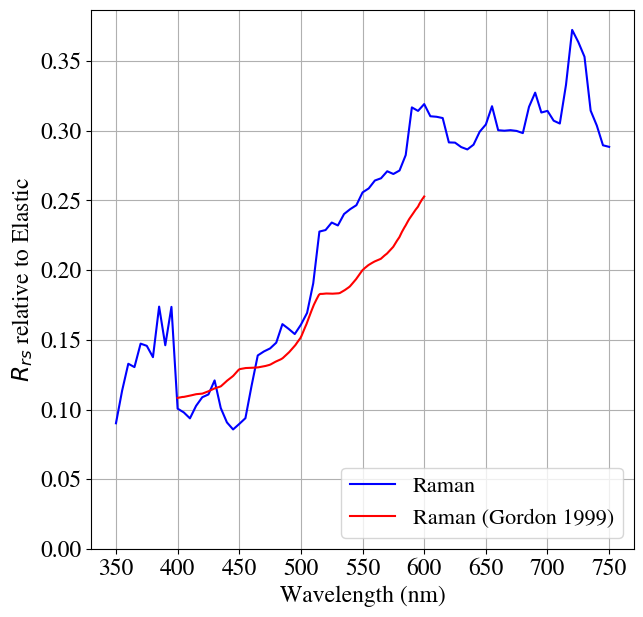

In [39]:
fig = plt.figure(figsize=(7,7))
ax = plt.gca()
#
ax.plot(wave, (Rrs_20-Rrs_10)/Rrs_10, label='Raman', color='blue')
ax.plot(wv, R_E/3.5, label='Raman (Gordon 1999)', color='red')
#
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel(r'$R_{rs}$ relative to Elastic')
ax.grid()
ax.set_ylim(0., None)
plotting.set_fontsize(ax, 17.)
ax.legend(loc='lower right', fontsize=16.)
plt.show()